In [1]:
import os, sys
sys.path.append(os.path.abspath('../..'))
from utlis.sync_utlis.general_loader import load_flat_with_frame_map, merge_pred_with_miniscope
from utlis.sync_utlis.general_loader_viz import plot_two_coms_from_pred_df


oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
rec_path = os.path.join(oct3v1, "2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30")
nc_key='wnd1500_stp700_max25_diff3.5_pnr1.1'
dannce_folder='SDANNCE/predict00'


merged = merge_pred_with_miniscope(
    rec_path=rec_path,
    nc_key=nc_key,
    dannce_folder=dannce_folder,
    com_folder=None,
    save_h5=False,
    save_csv=False,
)

merged.shape, merged.index[:3]

((12700, 273), Index([-5, 35, 64], dtype='int64', name='timestamp_ms_mini'))

In [2]:
from utlis.social_analysis.approaching import compute_com_distance, compute_motion_direction, detect_approaches
# 0) If you want distance only
dist = compute_com_distance(merged, p1="com1", p2="com2", smooth_window=5)
print(dist.head())

# 1) Motion vectors / directions for each animal
m1 = compute_motion_direction(merged, prefix="com1", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)
m2 = compute_motion_direction(merged, prefix="com2", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)
print(m1.filter(like="_speed").head(), m2.filter(like="_speed").head())

# 2) Detect approach windows (tune thresholds as you like)
res = detect_approaches(
    merged,
    p1="com1", p2="com2",
    time_col="timestamp_ms_mini",   # if absent, pass fps=...
    pos_smooth=5, vel_smooth=5,
    radial_thresh=20.0,             # mm/s toward the other
    speed_min=5.0,                  # mm/s total speed floor
    dist_min=None,                  # e.g., set 50.0 to ignore near-collisions if needed
    dist_max=300.0,                 # focus on interaction zone
    min_samples=15,                 # ≥15 consecutive frames
    return_intervals=True
)

# Per-frame booleans + metrics
res["frames"][["dist_mm","radial1","radial2","approach1","approach2","mutual"]].head()

# Interval summaries (list of dicts)
res["intervals"]["approach1"][:3], res["intervals"]["approach2"][:3], res["intervals"]["mutual"][:3]


timestamp_ms_mini
-5      50.580713
 35     50.694257
 64     50.803232
 97     50.946379
 130    51.173287
Name: dist_mm, dtype: float64
                   com1_speed
timestamp_ms_mini            
-5                   0.154367
 35                  0.162126
 64                  0.167439
 97                  0.159762
 130                 0.147180                    com2_speed
timestamp_ms_mini            
-5                   0.047668
 35                  0.057717
 64                  0.065080
 97                  0.077614
 130                 0.081325


([], [], [])

(<Figure size 1000x350 with 1 Axes>,
 <Axes: title={'center': 'Approach-success events (n=4)'}, xlabel='frame', ylabel='distance (mm)'>)

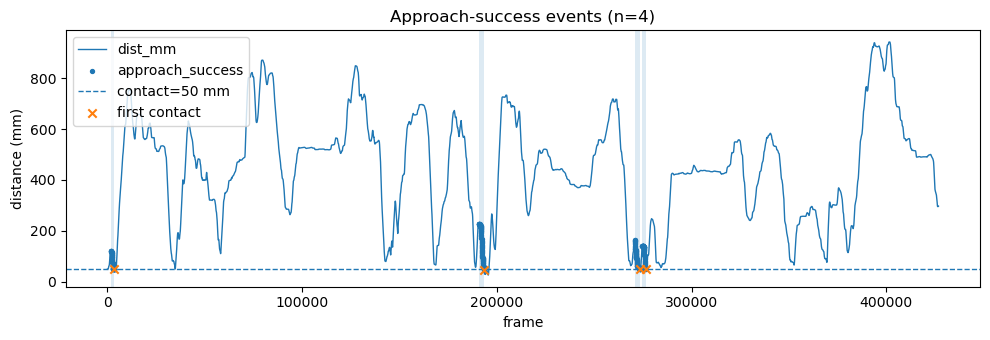

In [35]:
from utlis.social_analysis.approaching import find_approach_success, plot_dist_with_events
contact_mm = 50
# --- choose a setting (use your "best" from the sweep) ---
mask, events = find_approach_success(
    res["frames"],
    contact_mm=contact_mm,
    dD_dt_thresh=0.0,
    min_len=1,
    min_drop_mm=1#10.0
)
frames = res["frames"]

# --- global plot with event spans (uses the helper we wrote) ---
plot_dist_with_events(frames, mask, events, contact_mm=contact_mm)

# --- quick QA: first 3 events as small windows ---
# for ev in events[:3]:
#     plot_single_event(frames, ev, contact_mm=contact_mm)




In [36]:
from utlis.social_analysis.approaching import find_approach_success
from utlis.vis_valid_utlis.sdannce_vis import cfg, visualize_frames

C = cfg(base_path="/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30", cammm=1, 
        enable_zoom=True, zoom_margin=450, video_fps=30) #animal="mouse20", #write_pngs=True

# 0) Run your detector first
mask, events = find_approach_success(
    res["frames"],
    contact_mm=contact_mm,
    dD_dt_thresh=0.0,
    min_len=1,
    min_drop_mm=1.0
)

frames = res["frames"]
frame_col = "camera_frame_sixcam" if "camera_frame_sixcam" in frames.columns \
    else ("mapped_sixcam_frame_indices" if "mapped_sixcam_frame_indices" in frames.columns else None)

print(f"#approach_success events: {len(events)}")

incident_all_six_cam = frames.loc[mask, frame_col].astype(int).tolist() if frame_col else frames.index[mask].tolist()

# visualize_frames(incident_all_six_cam, config=C, out_name=f"specifc_frame_all_incidents_contact{contact_mm}_dD0_min1d1")

#approach_success events: 4


In [38]:
len(incident_all_six_cam)

254

In [5]:
import pandas as pd

def events_begin_end_cam_ts(events, frames):
    """
    events: list[dict] with 'start_idx', 'end_idx_exclusive' (0-based iloc)
    frames: DataFrame indexed by 'timestamp_ms_mini' and with 'camera_frame_sixcam' column
    """
    f = frames.reset_index()[['timestamp_ms_mini', 'camera_frame_sixcam']]  # make iloc simple

    def pick(i):
        r = f.iloc[int(i)]
        return int(r['camera_frame_sixcam']), r['timestamp_ms_mini']

    rows = [{
        'start_idx': e['start_idx'],
        'end_idx_exclusive': e['end_idx_exclusive'],
        'start_camera_frame_sixcam': pick(e['start_idx'])[0],
        'start_timestamp_ms_mini':   pick(e['start_idx'])[1],
        'end_camera_frame_sixcam':   pick(e['end_idx_exclusive'] - 1)[0],
        'end_timestamp_ms_mini':     pick(e['end_idx_exclusive'] - 1)[1],
    } for e in events]

    return pd.DataFrame(rows)


In [6]:
out = events_begin_end_cam_ts(events, frames)
out

,start_idx,end_idx_exclusive,start_camera_frame_sixcam,start_timestamp_ms_mini,end_camera_frame_sixcam,end_timestamp_ms_mini
0,57,105,260,1910,307,3491
1,5680,5754,5926,190888,6000,193341
2,8058,8140,8322,270803,8404,273526
3,8174,8224,8439,274702,8489,276349


In [7]:
from utlis.social_analysis.vis_mini import write_frames_video_by_fileidx_ffmpeg_fast, map_exact_timestamps_to_frames_with_buffer

csv_path = "/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20240919-V1-R1/customEntValHere/2024_12_18/11_33_01/My_V4_Miniscope/timeStamps.csv"
video_dir = "/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20240919-V1-R1/customEntValHere/2024_12_18/11_33_01/My_V4_Miniscope/"
out_path  = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/MIR_Aligned/vis/selected_frames.avi"

timestamps_ms = frames.index[mask] #[-5, 35, 64, 97]  # your exact list (ms) 

sel = map_exact_timestamps_to_frames_with_buffer(csv_path, timestamps_ms)

# info = write_frames_video_by_fileidx_ffmpeg_fast(
#     video_dir=video_dir,
#     selections_df=sel,       # needs columns: ['timestamp_ms','frame_number', ...]
#     out_path=out_path,
#     fps=None,                # use metaData.json frameRate
#     preset="ultrafast"
# )

# print(info)
# assert info["rendered_frames"] == len(sel)

# info

In [20]:
def write_frames_video_by_fileidx_ffmpeg_fast_overlay(
    video_dir, selections_df, out_path, fps=None, preset="ultrafast",
    rec_path=None, nc_file=None, mini_path_file="sync_to_mini_path.txt"
):
    """
    Fast FFmpeg path, robust for FFV1.
    - Derives file index from global frame number and framesPerFile.
    - Validates indices against actual nb_frames per file (drops OOR gracefully).
    - Uses select='eq(n,...) + eq(n,...)' to avoid comma escaping.
    - NEW: If `rec_path` and `nc_file` are provided, overlays Minian ROI edges from the .nc
           selected by `nc_file` (key substring match). The overlay is built once into a
           temp RGBA frame and looped by ffmpeg during encode.
    """
    from pathlib import Path
    import os, shutil, tempfile, subprocess
    import numpy as np

    video_dir = Path(video_dir)
    os.makedirs(Path(out_path).parent, exist_ok=True)

    meta = load_miniscope_meta(video_dir)
    fps_use = float(meta["frameRate"] if fps is None else fps)
    fpf = int(meta["framesPerFile"])

    S = selections_df.copy()
    S["file_idx"] = (S["frame_number"] // fpf).astype(int)
    S["local"]    = (S["frame_number"] %  fpf).astype(int)
    S = S.sort_values("timestamp_ms").reset_index(drop=True)

    tmpdir = Path(tempfile.mkdtemp(prefix="mini_fast_"))
    extracted = {}  # (file_idx, local) -> path
    overlay_png = None
    try:
        # 0) Optional: build overlay from Minian nc (only once)
        if rec_path and nc_file:
            overlay_png = _build_minian_edges_overlay_png(
                rec_path=Path(rec_path),
                mini_path_file=mini_path_file,
                nc_key=str(nc_file),
                out_png=tmpdir / "overlay_rgba.png",
            )

        # 1) Batch-extract per file
        for fi, group in S.groupby("file_idx"):
            fi = int(fi)
            src = video_dir / f"{fi}.avi"
            if not src.exists():
                raise FileNotFoundError(f"Missing split file: {src}")

            try:
                nb = _ffprobe_nb_frames(src)
            except Exception as e:
                raise RuntimeError(f"ffprobe failed on {src}: {e}")

            locals_req = sorted(set(int(x) for x in group["local"].tolist()))
            locals_ok  = [x for x in locals_req if 0 <= x < nb]
            if not locals_ok:
                continue

            vf = _build_select_eq(locals_ok)
            out_pat = tmpdir / f"buf{fi}_%06d.png"

            cmd = [
                "ffmpeg","-y","-hide_banner","-loglevel","error",
                "-i", str(src),
                "-vf", vf,
                "-vsync","vfr",
                str(out_pat)
            ]
            cp = subprocess.run(cmd, capture_output=True, text=True)
            if cp.returncode != 0:
                raise RuntimeError(
                    f"ffmpeg extract failed for {src}\n"
                    f"vf={vf}\n"
                    f"stderr:\n{cp.stderr}"
                )

            emitted = sorted(out_pat.parent.glob(f"buf{fi}_*.png"))
            if len(emitted) != len(locals_ok):
                if len(emitted) == 0:
                    raise RuntimeError(f"No frames emitted for {src} with vf={vf}")

            for loc, png in zip(locals_ok, emitted):
                extracted[(fi, int(loc))] = png

        # 2) Assemble in requested order (skip any failed extraction)
        seq_dir = tmpdir / "seq"
        seq_dir.mkdir(exist_ok=True)
        seq_files = []
        for _, row in S.iterrows():
            key = (int(row["file_idx"]), int(row["local"]))
            if key not in extracted:
                continue
            src_png = extracted[key]
            dst = seq_dir / f"f_{len(seq_files)+1:06d}.png"
            try:
                os.link(src_png, dst)
            except Exception:
                shutil.copy2(src_png, dst)
            seq_files.append(dst)

        if not seq_files:
            raise RuntimeError("No frames extracted — check indices vs nb_frames and codec support.")

        # 3) Single encode pass (+ optional overlay)
        if overlay_png and overlay_png.exists():
            cmd = [
                "ffmpeg","-y","-hide_banner","-loglevel","error",
                "-framerate", str(fps_use),
                "-i", str(seq_dir / "f_%06d.png"),
                # loop static overlay so it spans the full video
                "-loop","1","-i", str(overlay_png),
                # scale overlay to base only if needed, then overlay
                "-filter_complex", "[1:v][0:v]scale2ref[ol][base];[base][ol]overlay=0:0:format=auto",
                "-shortest",
                "-c:v","libx264","-preset", preset, "-pix_fmt","yuv420p",
                str(out_path)
            ]
        else:
            cmd = [
                "ffmpeg","-y","-hide_banner","-loglevel","error",
                "-framerate", str(fps_use),
                "-i", str(seq_dir / "f_%06d.png"),
                "-c:v","libx264","-preset", preset, "-pix_fmt","yuv420p",
                str(out_path)
            ]

        cp = subprocess.run(cmd, capture_output=True, text=True)
        if cp.returncode != 0:
            raise RuntimeError(f"ffmpeg encode failed:\n{cp.stderr}")

        return {
            "requested": len(S),
            "rendered_frames": len(seq_files),
            "fps": fps_use,
            "preset": preset,
            "out": str(out_path),
            "overlay": bool(overlay_png),
            "overlay_src": str(overlay_png) if overlay_png else None,
        }
    except Exception:
        # keep tmpdir for inspection on error
        raise


def _build_minian_edges_overlay_png(rec_path, mini_path_file, nc_key, out_png):
    """
    Build a transparent RGBA overlay (ROI edges) from a Minian .nc selected by `nc_key`.
    Returns Path to the created PNG. Uses fixed style: red edges @ alpha=0.35, no labels.
    """
    from pathlib import Path
    import os, re
    import numpy as np
    from PIL import Image
    import xarray as xr
    from scipy.ndimage import binary_erosion

    EDGE_ALPHA = 0.35
    EDGE_COLOR = (255, 0, 0)  # RGB

    # 1) miniscope root from {rec_path}/{mini_path_file}
    mini_path_txt = Path(rec_path) / mini_path_file
    with open(mini_path_txt, "r") as f:
        mini_root = Path(f.read().strip())

    # 2) locate .nc by key (prefer exact stem match, else newest containing key)
    nc_candidates = list(mini_root.rglob("*.nc"))
    exact = [p for p in nc_candidates if p.stem == nc_key]
    if exact:
        nc_path = exact[0]
    else:
        containing = [p for p in nc_candidates if nc_key in p.name]
        if not containing:
            raise FileNotFoundError(f"No .nc found under {mini_root} matching key '{nc_key}'")
        nc_path = max(containing, key=lambda p: p.stat().st_mtime)

    # 3) read A + max_proj
    ds = xr.open_dataset(nc_path)
    if "max_proj" not in ds or "A" not in ds:
        raise KeyError(f"'A' or 'max_proj' not found in {nc_path}")

    max_proj = ds["max_proj"].values  # (H, W)
    H, W = int(max_proj.shape[0]), int(max_proj.shape[1])

    A = ds["A"].values  # expect (n_rois, H*W) dense
    if A.ndim != 2 or A.shape[1] != H * W:
        # try to coerce if stored with extra dims (n_rois, H, W)
        if A.ndim == 3 and A.shape[1] * A.shape[2] == H * W:
            A = A.reshape(A.shape[0], H * W)
        else:
            raise ValueError(f"Unexpected 'A' shape {A.shape}, expected (n_rois, H*W) or (n_rois,H,W)")

    # 4) edge mask
    overlay_edges = np.zeros((H, W), dtype=np.uint8)
    # simple, deterministic; vectorization here is not worth the readability hit
    for roi in range(A.shape[0]):
        roi_mask = (A[roi].reshape(H, W) > 0)
        roi_edge = roi_mask ^ binary_erosion(roi_mask, border_value=0)
        # OR into a single mask
        overlay_edges |= roi_edge.astype(np.uint8)

    # 5) RGBA: transparent background, red edges with fixed alpha
    rgba = np.zeros((H, W, 4), dtype=np.uint8)
    rgba[..., 0] = EDGE_COLOR[0]
    rgba[..., 1] = EDGE_COLOR[1]
    rgba[..., 2] = EDGE_COLOR[2]
    rgba[..., 3] = (overlay_edges * int(EDGE_ALPHA * 255)).astype(np.uint8)

    Image.fromarray(rgba, mode="RGBA").save(out_png)
    return Path(out_png)


In [25]:
frames.shape

(12700, 10)

In [21]:
out_path

'/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/MIR_Aligned/demo_vids/mini_overlays/overlay.avi'

In [33]:
sel

,timestamp_ms,frame_number,buffer_idx
0,1910,57,0
1,1945,58,0
2,1978,59,0
3,2011,60,0
4,2044,61,0
...,...,...,...
249,276216,8219,0
250,276247,8220,0
251,276283,8221,0
252,276317,8222,0


In [22]:
info = write_frames_video_by_fileidx_ffmpeg_fast_overlay(
    video_dir=video_dir,
    selections_df=sel,
    out_path=out_path,
    fps=None,
    preset="ultrafast",
    rec_path=rec_path,                  # <— new
    nc_file=nc_key #'wnd1500_stp700_max25_diff3.5_pnr1.1'  # <— your nc key
)


In [15]:
out_path = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/MIR_Aligned/demo_vids/mini_overlays/overlay.avi"